In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


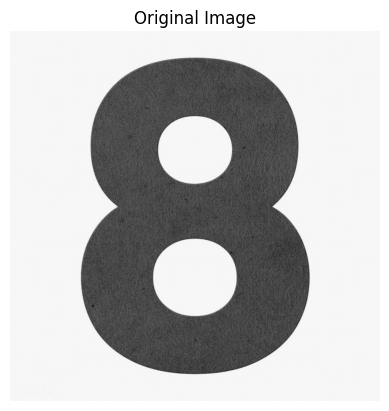

In [25]:
img1 = cv2.imread('eight.jpg')
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

plt.imshow(gray1,cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()

## how can we add guassian noise ?

1 generate normal ditribution with sigma and m

2-once i create normal ditribution create a matrix with the same shape as the image 

where this matrix fill with random number or random sampling values from normal ditribution i created befor .

In [26]:
mean = 0
sigma = 100

gaussian = np.random.normal(mean, sigma, gray1.shape)#This creates a noise matrix same size as image
noisy_img = gray1 + gaussian

noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

# If μ=0:
→ brightness stays roughly the same

# If σ increases:
→ noise becomes stronger

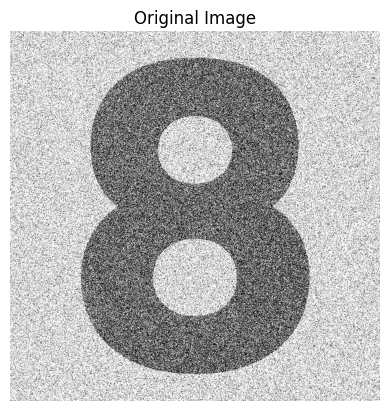

In [27]:
plt.imshow(noisy_img, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()

In [28]:
avg3 = cv2.blur(noisy_img, (3,3))
avg5 = cv2.blur(noisy_img, (5,5))
med3 = cv2.medianBlur(noisy_img, 3)
med5 = cv2.medianBlur(noisy_img, 5)

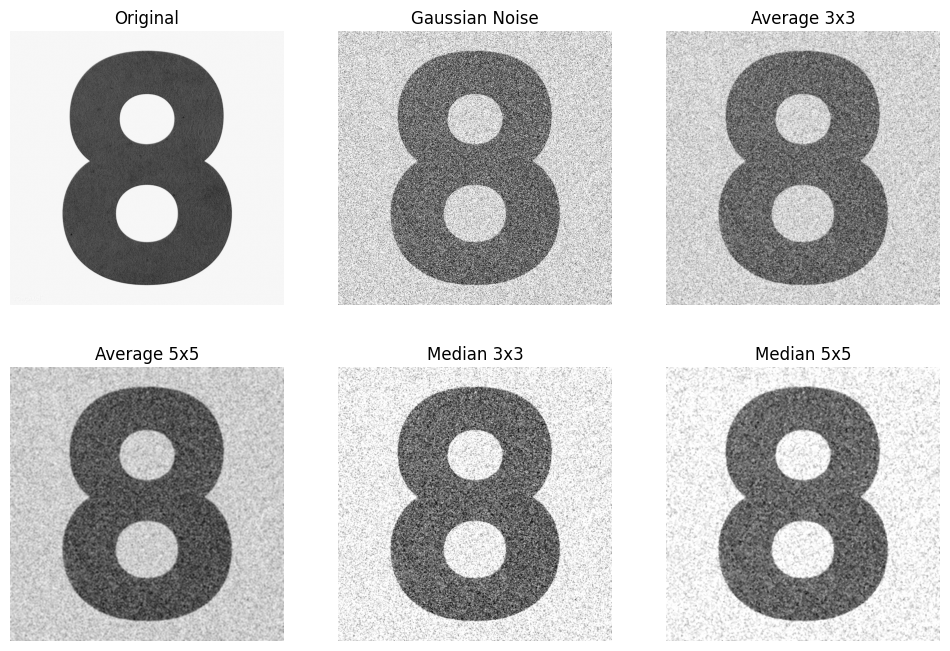

In [29]:
plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.title("Original")
plt.imshow(gray1, cmap='gray')
plt.axis('off')

plt.subplot(2,3,2)
plt.title("Gaussian Noise")
plt.imshow(noisy_img, cmap='gray')
plt.axis('off')

plt.subplot(2,3,3)
plt.title("Average 3x3")
plt.imshow(avg3, cmap='gray')
plt.axis('off')

plt.subplot(2,3,4)
plt.title("Average 5x5")
plt.imshow(avg5, cmap='gray')
plt.axis('off')

plt.subplot(2,3,5)
plt.title("Median 3x3")
plt.imshow(med3, cmap='gray')
plt.axis('off')

plt.subplot(2,3,6)
plt.title("Median 5x5")
plt.imshow(med5, cmap='gray')
plt.axis('off')

plt.show()


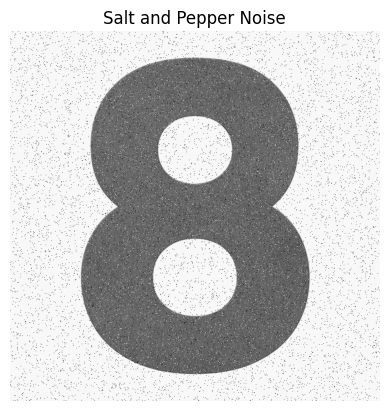

In [30]:
import numpy as np

def add_salt_pepper_noise(image, prob=0.02):
    noisy = image.copy()
    
    # Salt (white pixels)
    salt = np.random.rand(*image.shape) < (prob)
    noisy[salt] = 255

    # Pepper (black pixels)
    pepper = np.random.rand(*image.shape) < (prob)
    noisy[pepper] = 0

    return noisy
salt_pepper_img = add_salt_pepper_noise(gray1) 
plt.imshow(salt_pepper_img, cmap='gray')
plt.title("Salt and Pepper Noise")
plt.axis("off")
plt.show()  

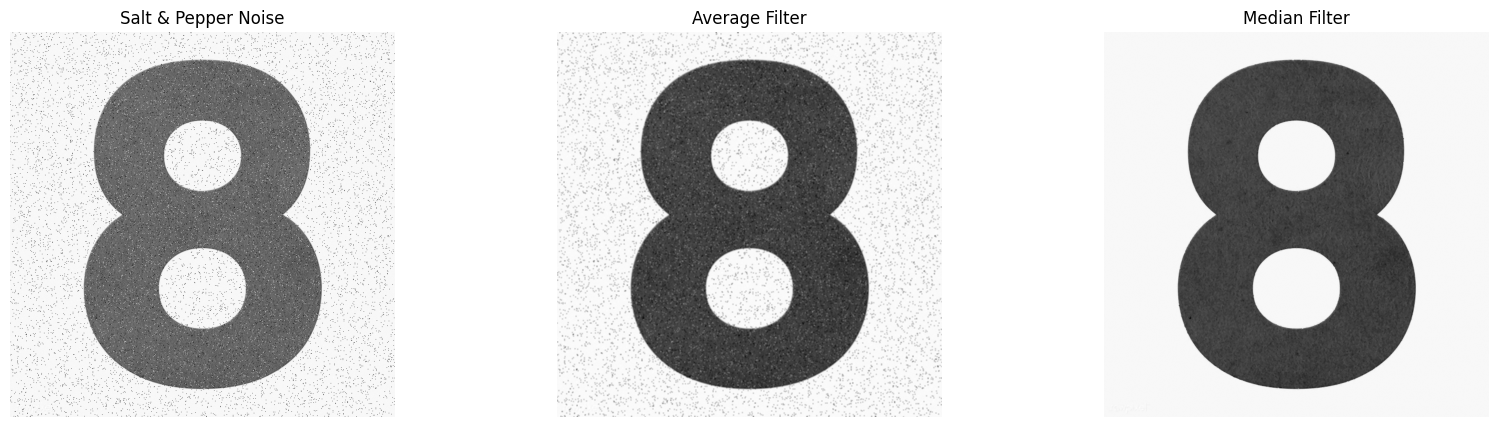

In [31]:
avg = cv2.blur(salt_pepper_img, (3,3))
median = cv2.medianBlur(salt_pepper_img, 3)


plt.figure(figsize=(20,5))

plt.subplot(1,3,1)
plt.title("Salt & Pepper Noise")
plt.imshow(salt_pepper_img, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Average Filter")
plt.imshow(avg, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Median Filter")
plt.imshow(median, cmap='gray')
plt.axis('off')

plt.show()



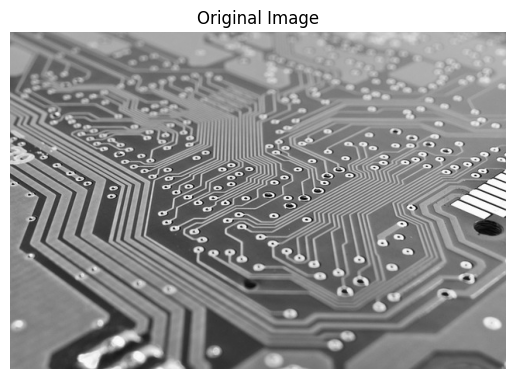

In [32]:
img2 = cv2.imread('circuit.jpg')
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

plt.imshow(gray2,cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()

## cv2.convertScaleAbs() does 3 things at once:

1-Takes absolute value → removes negative signs

2-Scales values (if needed)

3-Converts to uint8 (0 → 255)

In [33]:
sobelx = cv2.Sobel(gray2, cv2.CV_64F, 1, 0, ksize=3)
sobelx = cv2.convertScaleAbs(sobelx)
sobely = cv2.Sobel(gray2, cv2.CV_64F, 0, 1, ksize=3)
sobely = cv2.convertScaleAbs(sobely)
laplacian = cv2.Laplacian(gray2, cv2.CV_64F)
laplacian = cv2.convertScaleAbs(laplacian)



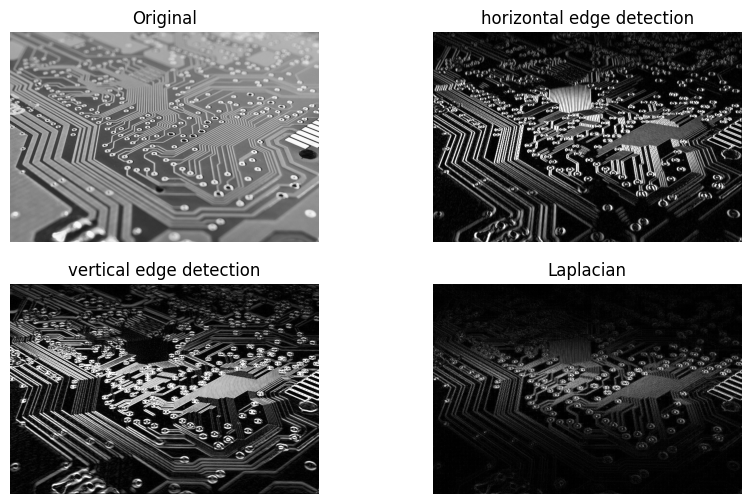

In [34]:
plt.figure(figsize=(10,6))

plt.subplot(2,2,1)
plt.title("Original")
plt.imshow(gray2, cmap='gray')
plt.axis('off')

plt.subplot(2,2,2)
plt.title("horizontal edge detection")
plt.imshow(sobelx, cmap='gray')
plt.axis('off')

plt.subplot(2,2,3)
plt.title("vertical edge detection")
plt.imshow(sobely, cmap='gray')
plt.axis('off')

plt.subplot(2,2,4)
plt.title("Laplacian")
plt.imshow(laplacian, cmap='gray')
plt.axis('off')

plt.show()


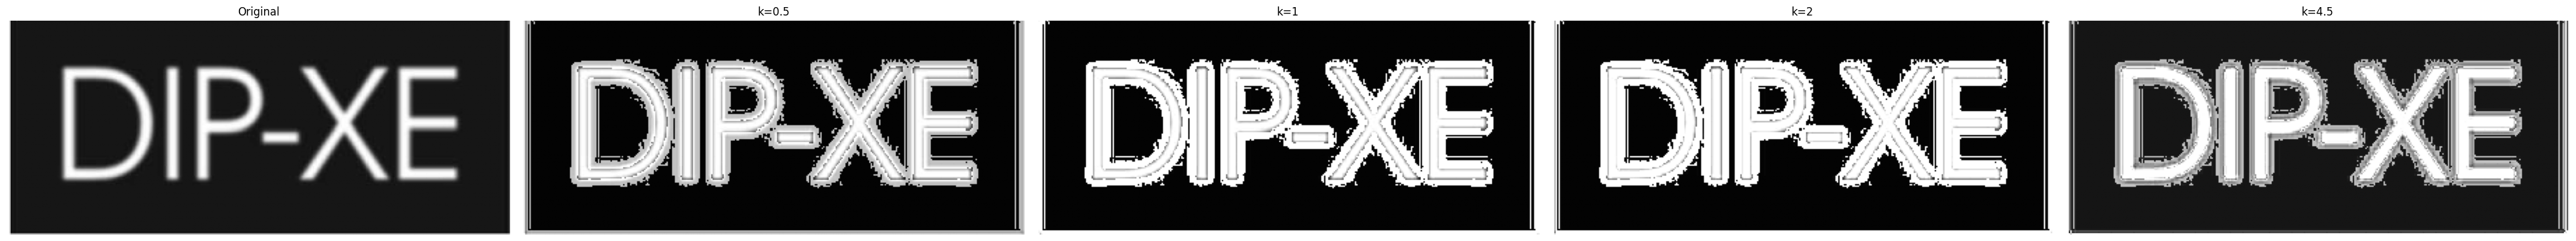

In [10]:
img3 = cv2.imread('Screenshot 2026-03-17 122023.png')
gray3 = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)

# Step 1: Blur
blur = cv2.blur(gray3, (5,5))

# Step 2: Mask
mask = gray3 - blur


k_values = [0.5,1, 2, 4.5]


plt.figure(figsize=(40,100))

plt.subplot(1, len(k_values)+1, 1)
plt.imshow(gray3, cmap='gray')
plt.title("Original")
plt.axis("off")

for i, k in enumerate(k_values):
    sharpened = cv2.add(gray3, (k * mask).astype(np.uint8))
    
    plt.subplot(1, len(k_values)+1, i+2)
    plt.imshow(sharpened, cmap='gray')
    plt.title(f"k={k}")
    plt.axis('off')

plt.tight_layout()
plt.show()
